In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("/content/sample_submission.csv")
data

,id,sexo
0,id_1,M
1,id_2,H
2,id_3,M


In [3]:
train = pd.read_csv('/content/train.csv')
train.head()



,id,sexo,longitudCraneo,longitudPico,longitudNarina,anchoCraneo,altoPico,anchoPico,tarso,longAlaCerrada,longAlaAbierta,mediaEnvergadura,envergadura,peso
0,0J4_2016,H,174.18,106.85,80.19,52.43,30.20,23.26,88.74,51.0,95.7,104.2,208.4,2.38
1,A68_2016,H,171.12,104.59,79.45,51.14,30.61,24.04,90.22,50.5,94.4,102.2,204.4,2.14
2,E55_2015,H,174.69,106.83,82.14,49.09,30.60,26.47,91.42,52.7,96.6,105.2,210.4,2.50
3,7C7_2016,M,182.25,113.17,84.13,52.26,32.08,26.07,91.74,52.6,98.9,107.6,215.2,2.83
4,2C0_2018,H,173.70,105.19,80.37,49.20,34.00,27.12,87.77,50.8,94.5,103.7,207.4,2.73


In [4]:
test=pd.read_csv("/content/test.csv")
test.head()

,id,longitudCraneo,longitudPico,longitudNarina,anchoCraneo,altoPico,anchoPico,tarso,longAlaCerrada,longAlaAbierta,mediaEnvergadura,envergadura,peso
0,A70_2018,183.57,117.18,87.90,53.60,33.10,26.50,95.70,52.5,98.6,104.4,208.8,3.35
1,5C9_2018,166.60,105.05,80.63,51.64,31.31,26.10,88.82,50.7,93.4,101.4,202.8,2.43
2,5E1_2018,175.53,111.23,84.93,53.74,32.75,24.93,91.42,51.3,94.2,103.4,206.8,2.99
3,C58_2018,187.85,116.90,87.52,54.22,35.10,27.00,99.48,52.3,99.8,107.6,215.2,3.55
4,5E2_2018,182.67,116.40,87.24,54.57,33.59,25.40,96.43,53.4,100.3,110.1,220.2,3.06


In [5]:
print("Missing values in train:")
print(train.isnull().sum())

print("\nMissing values in test:")
print(test.isnull().sum())

Missing values in train:
id                  0
sexo                0
longitudCraneo      0
longitudPico        0
longitudNarina      0
anchoCraneo         0
altoPico            0
anchoPico           0
tarso               0
longAlaCerrada      0
longAlaAbierta      0
mediaEnvergadura    0
envergadura         0
peso                1
dtype: int64

Missing values in test:
id                  0
longitudCraneo      0
longitudPico        0
longitudNarina      0
anchoCraneo         0
altoPico            0
anchoPico           0
tarso               0
longAlaCerrada      0
longAlaAbierta      0
mediaEnvergadura    0
envergadura         0
peso                0
dtype: int64


In [6]:
train["peso"].value_counts()

,count
peso,
2.55,5
2.50,3
2.21,3
2.85,3
2.38,3
...,...
3.08,1
2.07,1
3.17,1


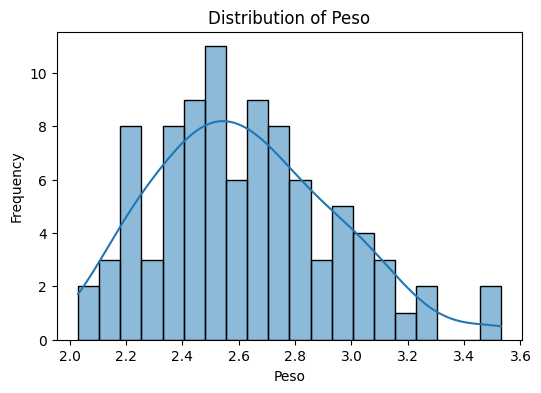

In [7]:
plt.figure(figsize=(6,4))

sns.histplot(train['peso'], kde=True, bins=20)

plt.title('Distribution of Peso')
plt.xlabel('Peso')
plt.ylabel('Frequency')

plt.show()

In [8]:
train['peso'] = train['peso'].fillna(train['peso'].median())

In [9]:
train.isnull().sum()

,0
id,0
sexo,0
longitudCraneo,0
longitudPico,0
longitudNarina,0
anchoCraneo,0
altoPico,0
anchoPico,0
tarso,0
longAlaCerrada,0


In [10]:
train.duplicated().sum()

np.int64(0)

In [11]:
test.duplicated().sum()

np.int64(0)

In [12]:
print("TRAIN INFO")
train.info()

print("\nTEST INFO")
test.info()

TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                94 non-null     object 
 1   sexo              94 non-null     object 
 2   longitudCraneo    94 non-null     float64
 3   longitudPico      94 non-null     float64
 4   longitudNarina    94 non-null     float64
 5   anchoCraneo       94 non-null     float64
 6   altoPico          94 non-null     float64
 7   anchoPico         94 non-null     float64
 8   tarso             94 non-null     float64
 9   longAlaCerrada    94 non-null     float64
 10  longAlaAbierta    94 non-null     float64
 11  mediaEnvergadura  94 non-null     float64
 12  envergadura       94 non-null     float64
 13  peso              94 non-null     float64
dtypes: float64(12), object(2)
memory usage: 10.4+ KB

TEST INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40

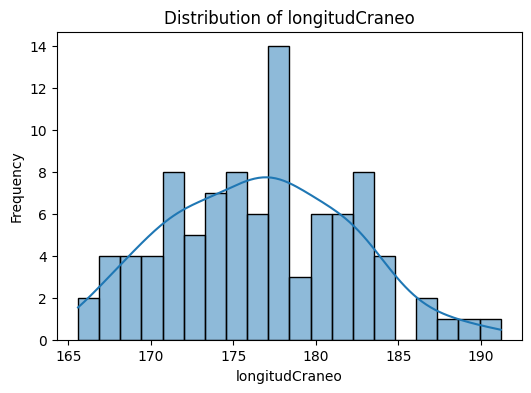

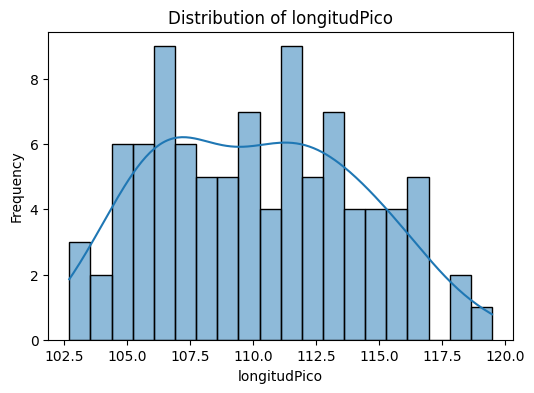

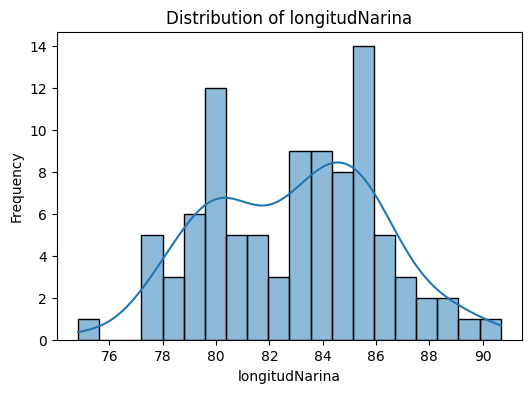

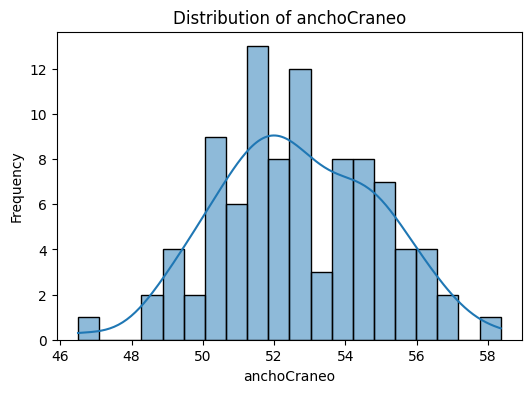

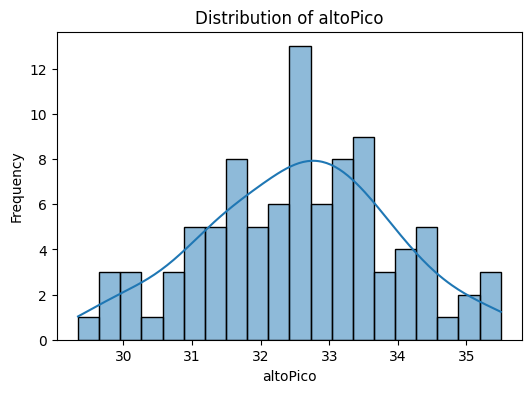

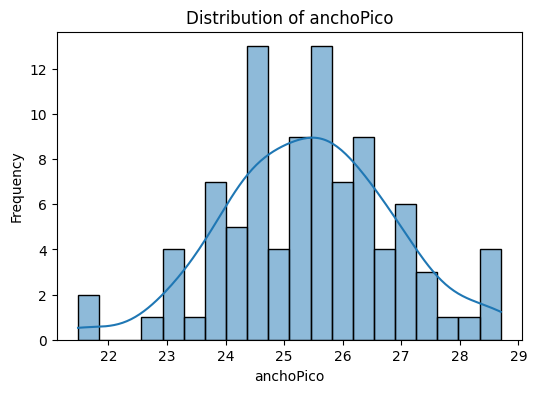

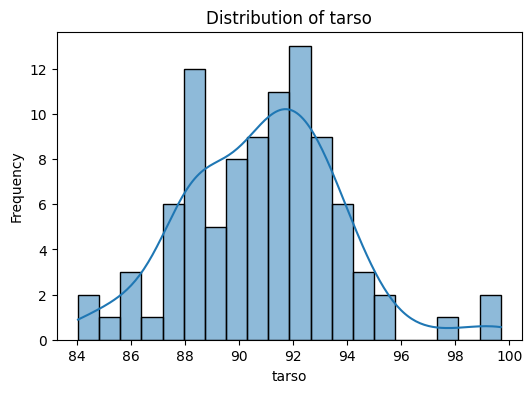

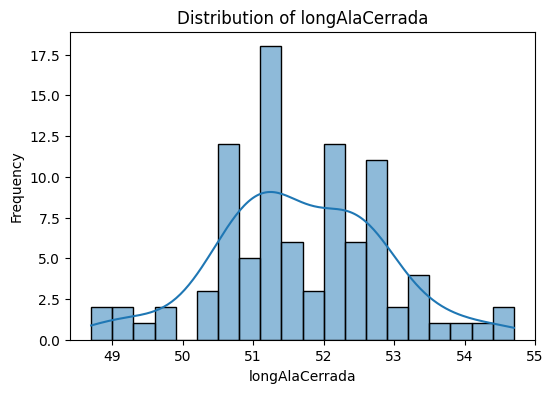

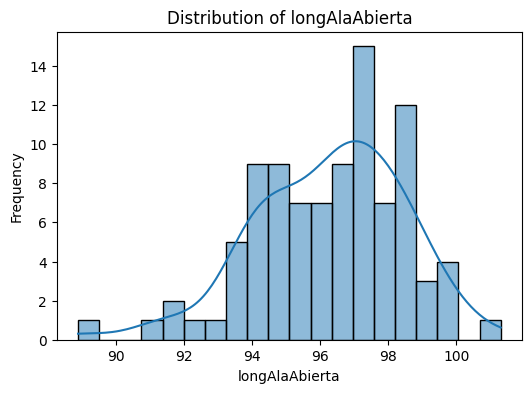

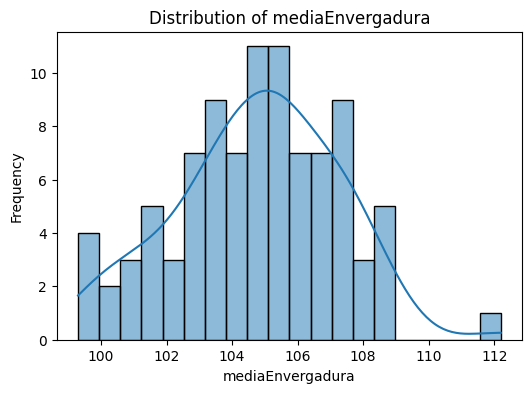

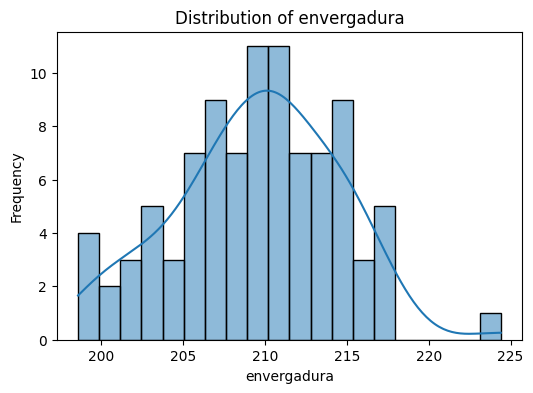

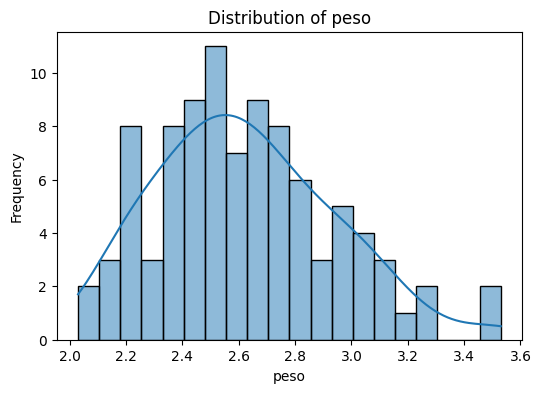

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_columns = train.select_dtypes(include='number').columns

for column in numeric_columns:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        data=train,
        x=column,
        bins=20,
        kde=True
    )

    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

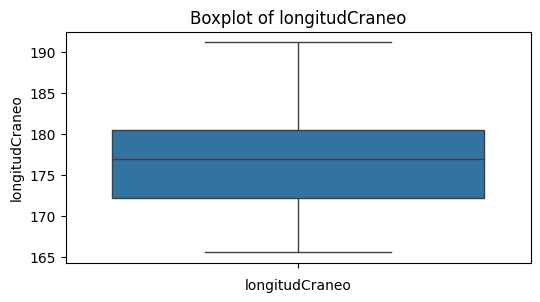

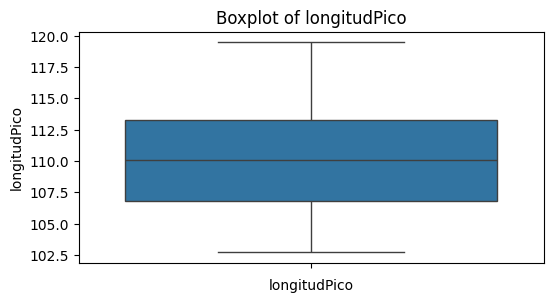

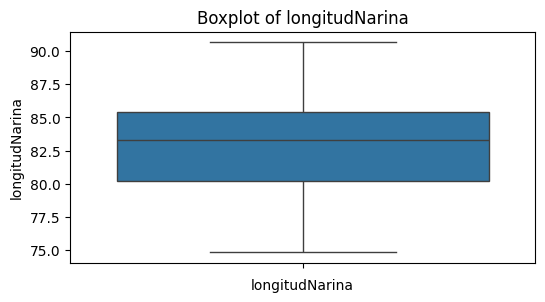

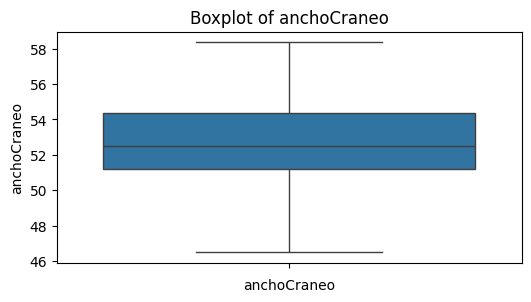

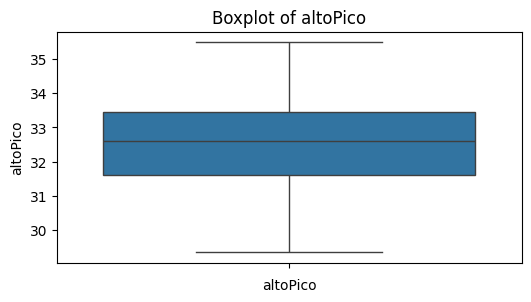

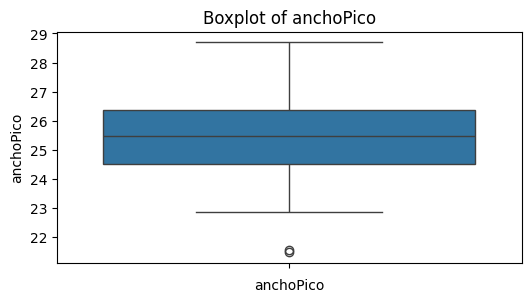

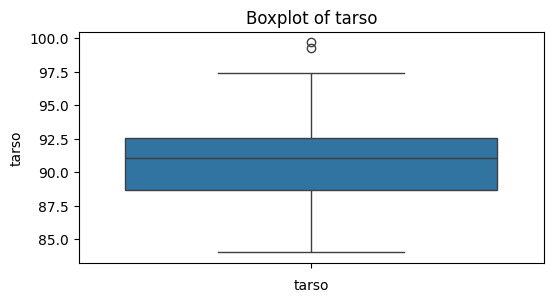

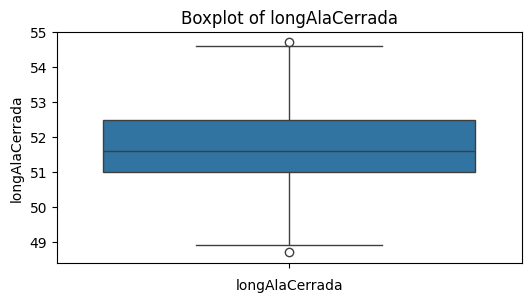

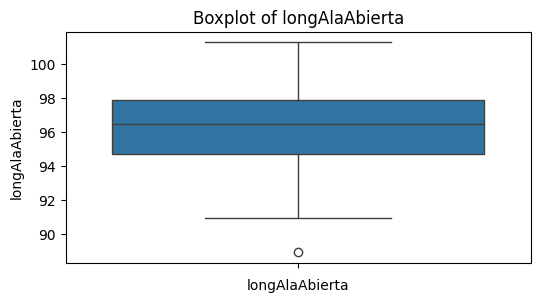

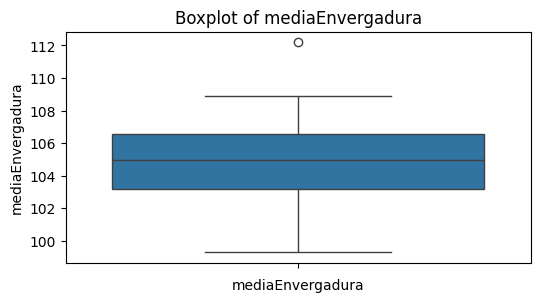

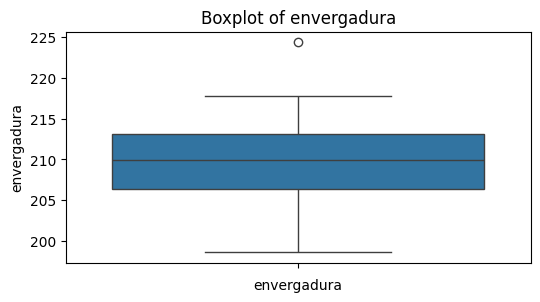

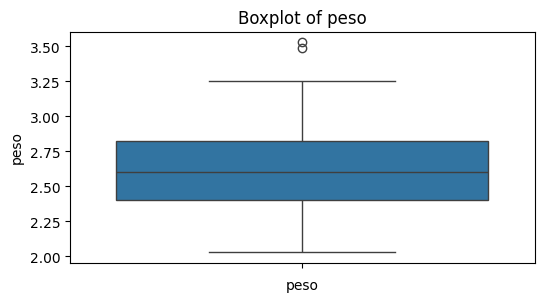

In [14]:
numeric_columns = train.select_dtypes(include='number').columns

for column in numeric_columns:
    plt.figure(figsize=(6, 3))

    sns.boxplot(y=train[column])

    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)

    plt.show()

In [14]:
from scipy.stats.mstats import winsorize

numeric_cols = train.select_dtypes(include='number').columns

for column in numeric_cols:
    train[column] = winsorize(train[column], limits=[0.03, 0.03])

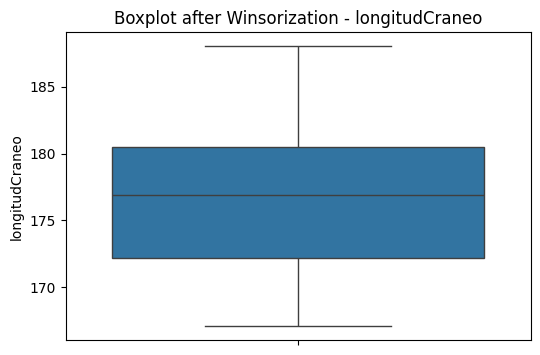

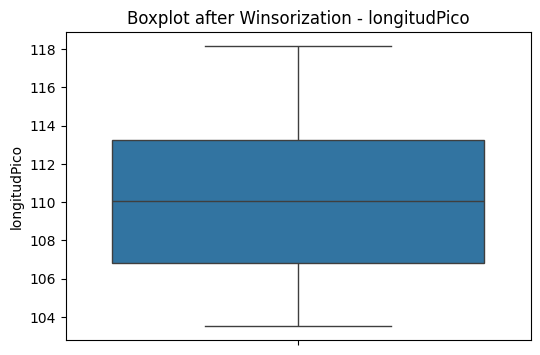

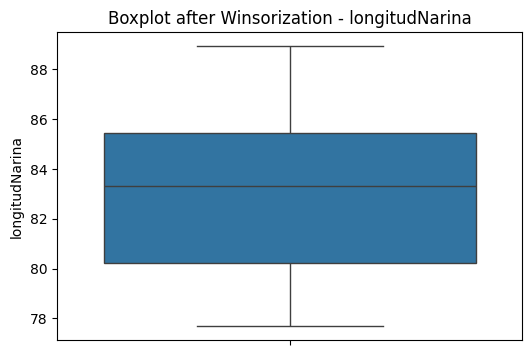

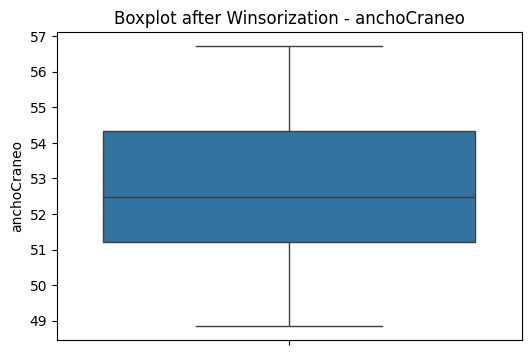

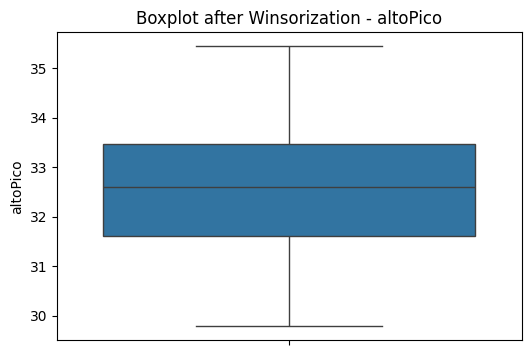

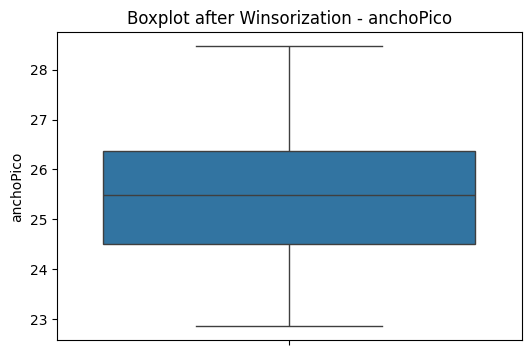

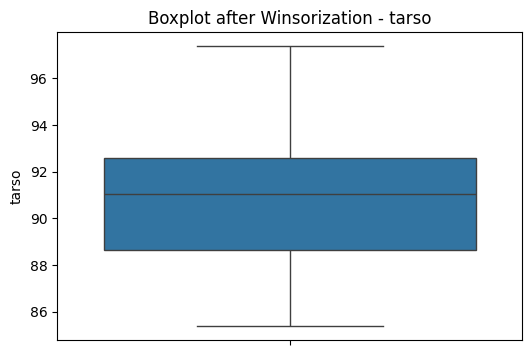

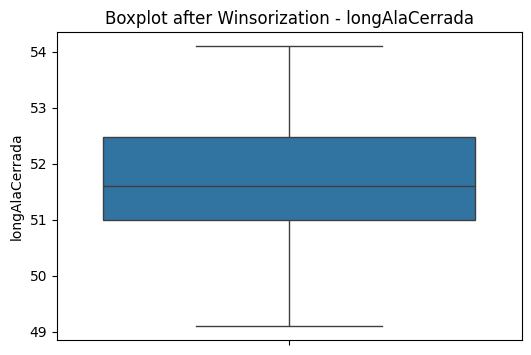

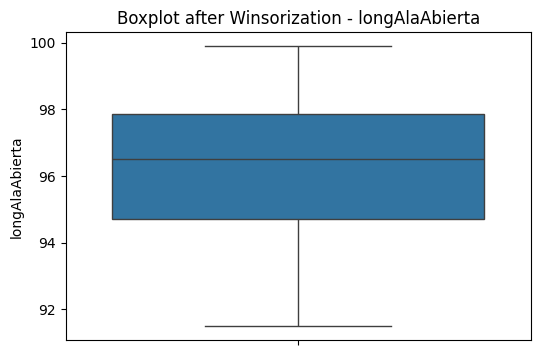

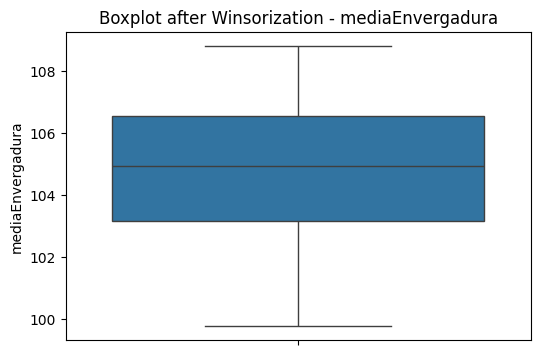

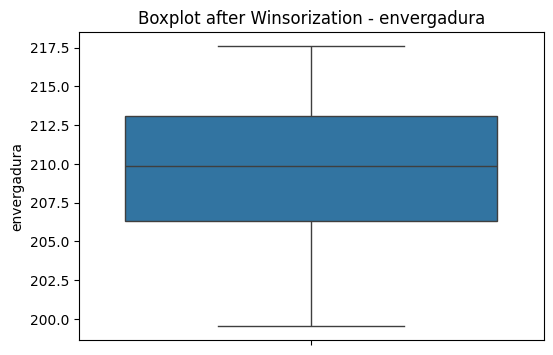

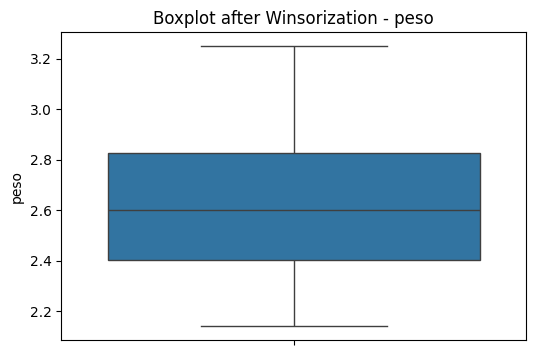

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = train.select_dtypes(include='number').columns

for column in numeric_cols:
    plt.figure(figsize=(6, 4))

    sns.boxplot(
        y=train[column]
    )

    plt.title(f'Boxplot after Winsorization - {column}')
    plt.ylabel(column)

    plt.show()

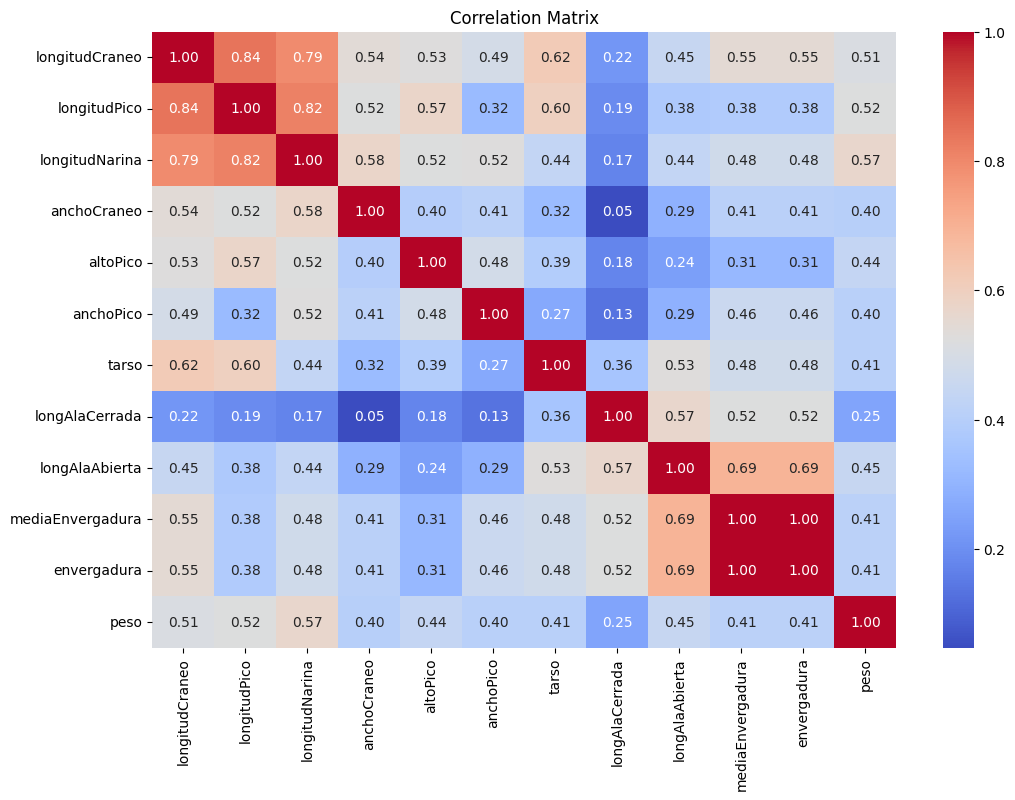

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    train.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train['sexo'] = le.fit_transform(train['sexo'])

print("Classes:", le.classes_)
print(train['sexo'].value_counts())

Classes: ['H' 'M']
sexo
0    57
1    37
Name: count, dtype: int64


In [18]:
train.head()

,id,sexo,longitudCraneo,longitudPico,longitudNarina,anchoCraneo,altoPico,anchoPico,tarso,longAlaCerrada,longAlaAbierta,mediaEnvergadura,envergadura,peso
0,0J4_2016,0,174.18,106.85,80.19,52.43,30.20,23.26,88.74,51.0,95.7,104.2,208.4,2.38
1,A68_2016,0,171.12,104.59,79.45,51.14,30.61,24.04,90.22,50.5,94.4,102.2,204.4,2.14
2,E55_2015,0,174.69,106.83,82.14,49.09,30.60,26.47,91.42,52.7,96.6,105.2,210.4,2.50
3,7C7_2016,1,182.25,113.17,84.13,52.26,32.08,26.07,91.74,52.6,98.9,107.6,215.2,2.83
4,2C0_2018,0,173.70,105.19,80.37,49.20,34.00,27.12,87.77,50.8,94.5,103.7,207.4,2.73


In [19]:
X = train.drop(columns=['id', 'sexo', 'envergadura'])
y = train['sexo']

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.columns)

X shape: (94, 11)
y shape: (94,)
Index(['longitudCraneo', 'longitudPico', 'longitudNarina', 'anchoCraneo',
       'altoPico', 'anchoPico', 'tarso', 'longAlaCerrada', 'longAlaAbierta',
       'mediaEnvergadura', 'peso'],
      dtype='object')


In [20]:
X_test = test.drop(columns=['id', 'envergadura'])

print("X_test shape:", X_test.shape)
print(X_test.columns)

X_test shape: (41, 11)
Index(['longitudCraneo', 'longitudPico', 'longitudNarina', 'anchoCraneo',
       'altoPico', 'anchoPico', 'tarso', 'longAlaCerrada', 'longAlaAbierta',
       'mediaEnvergadura', 'peso'],
      dtype='object')


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (75, 11)
X_val: (19, 11)
y_train: (75,)
y_val: (19,)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (75, 11)
X_val_scaled: (19, 11)
X_test_scaled: (41, 11)


In [23]:
X.skew().sort_values()

,0
longAlaAbierta,-0.349733
mediaEnvergadura,-0.314225
altoPico,-0.042749
longAlaCerrada,-0.042684
longitudNarina,0.007509
tarso,0.061543
anchoCraneo,0.092175
longitudCraneo,0.116963
longitudPico,0.169448
anchoPico,0.191558


In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_val_scaled)

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8947368421052632
Precision: 0.8571428571428571
Recall   : 0.8571428571428571
F1 Score : 0.8571428571428571


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

print(cm)

[[11  1]
 [ 1  6]]


In [27]:
print("Actual   :", y_val.values)
print("Predicted:", y_pred)

Actual   : [1 0 0 0 0 1 0 1 1 0 0 0 0 1 1 0 1 0 0]
Predicted: [1 0 1 0 0 0 0 1 1 0 0 0 0 1 1 0 1 0 0]


In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_val_scaled)

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_knn = accuracy_score(y_val, y_pred_knn)
precision_knn = precision_score(y_val, y_pred_knn)
recall_knn = recall_score(y_val, y_pred_knn)
f1_knn = f1_score(y_val, y_pred_knn)

print("Accuracy :", accuracy_knn)
print("Precision:", precision_knn)
print("Recall   :", recall_knn)
print("F1 Score :", f1_knn)

Accuracy : 0.8947368421052632
Precision: 0.8571428571428571
Recall   : 0.8571428571428571
F1 Score : 0.8571428571428571


In [30]:
from sklearn.metrics import confusion_matrix

cm_knn = confusion_matrix(y_val, y_pred_knn)

print(cm_knn)

[[11  1]
 [ 1  6]]


In [31]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_val_scaled)

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_dt = accuracy_score(y_val, y_pred_dt)
precision_dt = precision_score(y_val, y_pred_dt)
recall_dt = recall_score(y_val, y_pred_dt)
f1_dt = f1_score(y_val, y_pred_dt)

print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

Accuracy : 0.8421052631578947
Precision: 0.8333333333333334
Recall   : 0.7142857142857143
F1 Score : 0.7692307692307693


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_val_scaled)

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_rf = accuracy_score(y_val, y_pred_rf)
precision_rf = precision_score(y_val, y_pred_rf)
recall_rf = recall_score(y_val, y_pred_rf)
f1_rf = f1_score(y_val, y_pred_rf)

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Accuracy : 0.8947368421052632
Precision: 0.8571428571428571
Recall   : 0.8571428571428571
F1 Score : 0.8571428571428571


In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='f1'
)

grid_rf.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.9047619047619048


In [36]:
best_rf = grid_rf.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_val_scaled)

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_val, y_pred_rf_tuned))
print("Precision:", precision_score(y_val, y_pred_rf_tuned))
print("Recall   :", recall_score(y_val, y_pred_rf_tuned))
print("F1 Score :", f1_score(y_val, y_pred_rf_tuned))

Accuracy : 0.8421052631578947
Precision: 0.8333333333333334
Recall   : 0.7142857142857143
F1 Score : 0.7692307692307693


In [38]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=42)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_val_scaled)

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_val, y_pred_svm))
print("Precision:", precision_score(y_val, y_pred_svm))
print("Recall   :", recall_score(y_val, y_pred_svm))
print("F1 Score :", f1_score(y_val, y_pred_svm))

Accuracy : 0.8421052631578947
Precision: 0.8333333333333334
Recall   : 0.7142857142857143
F1 Score : 0.7692307692307693


In [40]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Random Forest', 'SVM'],
    'Accuracy': [accuracy, accuracy_knn, accuracy_rf, accuracy_score(y_val, y_pred_svm)],
    'Precision': [precision, precision_knn, precision_rf, precision_score(y_val, y_pred_svm)],
    'Recall': [recall, recall_knn, recall_rf, recall_score(y_val, y_pred_svm)],
    'F1 Score': [f1, f1_knn, f1_rf, f1_score(y_val, y_pred_svm)]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.894737,0.857143,0.857143,0.857143
1,KNN,0.894737,0.857143,0.857143,0.857143
2,Random Forest,0.894737,0.857143,0.857143,0.857143
3,SVM,0.842105,0.833333,0.714286,0.769231


In [41]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_val_scaled)

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_xgb = accuracy_score(y_val, y_pred_xgb)
precision_xgb = precision_score(y_val, y_pred_xgb)
recall_xgb = recall_score(y_val, y_pred_xgb)
f1_xgb = f1_score(y_val, y_pred_xgb)

print("Accuracy :", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall   :", recall_xgb)
print("F1 Score :", f1_xgb)

Accuracy : 0.8947368421052632
Precision: 0.8571428571428571
Recall   : 0.8571428571428571
F1 Score : 0.8571428571428571


In [43]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_xgb.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_xgb.best_params_)

print("\nBest CV F1 Score:")
print(grid_xgb.best_score_)

Best Parameters:
{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}

Best CV F1 Score:
0.8653679653679653


In [44]:
best_xgb = grid_xgb.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_val_scaled)

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_xgb_tuned = accuracy_score(y_val, y_pred_xgb_tuned)
precision_xgb_tuned = precision_score(y_val, y_pred_xgb_tuned)
recall_xgb_tuned = recall_score(y_val, y_pred_xgb_tuned)
f1_xgb_tuned = f1_score(y_val, y_pred_xgb_tuned)

print("Accuracy :", accuracy_xgb_tuned)
print("Precision:", precision_xgb_tuned)
print("Recall   :", recall_xgb_tuned)
print("F1 Score :", f1_xgb_tuned)

Accuracy : 0.8947368421052632
Precision: 0.8571428571428571
Recall   : 0.8571428571428571
F1 Score : 0.8571428571428571


In [46]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Random Forest',
        'SVM',
        'XGBoost',
        'Tuned XGBoost'
    ],
    'Accuracy': [
        accuracy,
        accuracy_knn,
        accuracy_rf,
        accuracy_score(y_val, y_pred_svm),
        accuracy_xgb,
        accuracy_xgb_tuned
    ],
    'Precision': [
        precision,
        precision_knn,
        precision_rf,
        precision_score(y_val, y_pred_svm),
        precision_xgb,
        precision_xgb_tuned
    ],
    'Recall': [
        recall,
        recall_knn,
        recall_rf,
        recall_score(y_val, y_pred_svm),
        recall_xgb,
        recall_xgb_tuned
    ],
    'F1 Score': [
        f1,
        f1_knn,
        f1_rf,
        f1_score(y_val, y_pred_svm),
        f1_xgb,
        f1_xgb_tuned
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.894737,0.857143,0.857143,0.857143
1,KNN,0.894737,0.857143,0.857143,0.857143
2,Random Forest,0.894737,0.857143,0.857143,0.857143
3,SVM,0.842105,0.833333,0.714286,0.769231
4,XGBoost,0.894737,0.857143,0.857143,0.857143
5,Tuned XGBoost,0.894737,0.857143,0.857143,0.857143


In [49]:
from sklearn.metrics import roc_auc_score

auc_lr = roc_auc_score(
    y_val,
    model.predict_proba(X_val_scaled)[:, 1]
)

auc_knn = roc_auc_score(
    y_val,
    knn.predict_proba(X_val_scaled)[:, 1]
)

auc_rf = roc_auc_score(
    y_val,
    best_rf.predict_proba(X_val_scaled)[:, 1]
)

auc_svm = roc_auc_score(
    y_val,
    svm.decision_function(X_val_scaled)
)

auc_xgb_tuned = roc_auc_score(
    y_val,
    best_xgb.predict_proba(X_val_scaled)[:, 1]
)

print("Logistic Regression AUC :", auc_lr)
print("KNN AUC                 :", auc_knn)
print("Random Forest AUC       :", auc_rf)
print("SVM AUC                 :", auc_svm)
print("Tuned XGBoost AUC       :", auc_xgb_tuned)

Logistic Regression AUC : 0.9047619047619049
KNN AUC                 : 0.8452380952380952
Random Forest AUC       : 0.9404761904761906
SVM AUC                 : 0.8928571428571429
Tuned XGBoost AUC       : 0.8928571428571429


In [50]:
y_test_pred = best_rf.predict(X_test_scaled)

print(y_test_pred)

[1 0 1 1 1 1 1 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 1 1 0 1 0 0 0
 0 1 1 1]


In [51]:
submission = pd.DataFrame({
    'id': test['id'],
    'sexo': y_test_pred
})

submission.head()

,id,sexo
0,A70_2018,1
1,5C9_2018,0
2,5E1_2018,1
3,C58_2018,1
4,5E2_2018,1


In [52]:
submission.to_csv('submission.csv', index=False)

print("Submission file created successfully!")

Submission file created successfully!


In [53]:
submission.shape

(41, 2)

In [54]:
submission.head()

,id,sexo
0,A70_2018,1
1,5C9_2018,0
2,5E1_2018,1
3,C58_2018,1
4,5E2_2018,1


In [55]:
from google.colab import files

files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>